In [2]:
import pandas as pd

In [3]:
loan = pd.read_csv('loan.csv')
loan.head()

,Income,Loan Amount,Default
0,15,8,No
1,30,8,No
2,5,9,Yes
3,22,10,No
4,33,12,No


In [4]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Income       30 non-null     int64 
 1   Loan Amount  30 non-null     int64 
 2   Default      30 non-null     object
dtypes: int64(2), object(1)
memory usage: 852.0+ bytes


In [9]:
loan.describe()

,Income,Loan Amount
count,30.000000,30.000000
mean,18.766667,51.966667
std,8.572946,34.055212
min,5.000000,8.000000
25%,13.000000,21.250000
50%,18.000000,49.000000
75%,25.500000,79.500000
max,34.000000,110.000000


In [5]:
%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns

<Axes: xlabel='Default', ylabel='Income'>

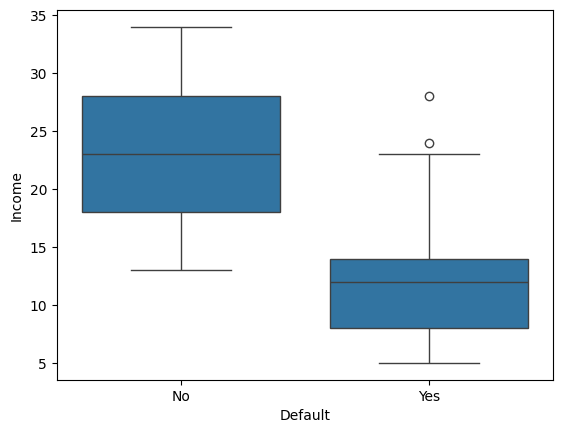

In [9]:
ax = sns.boxplot(data= loan, x = 'Default', y='Income')
ax

<Axes: xlabel='Default', ylabel='Loan Amount'>

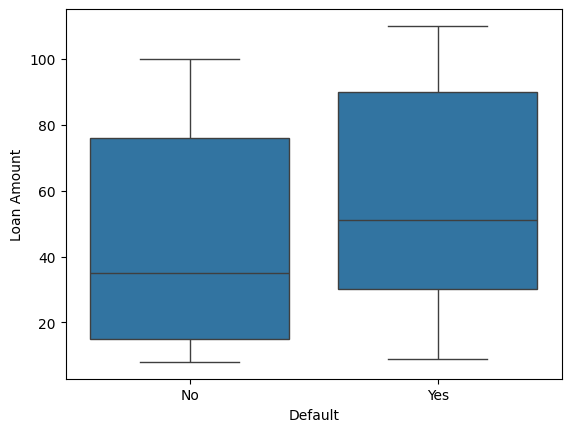

In [7]:
ax = sns.boxplot(data= loan, x = 'Default', y='Loan Amount')
ax

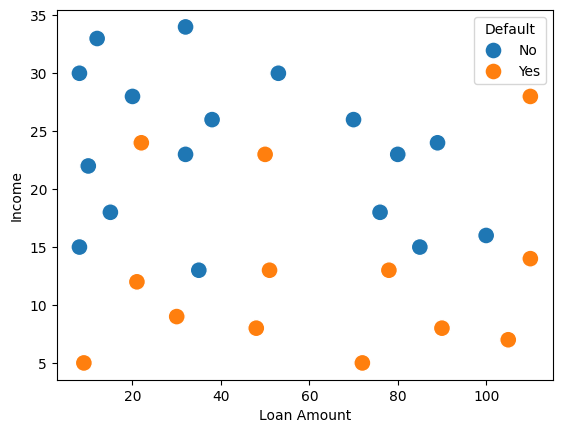

In [8]:
ax = sns.scatterplot(data=loan, x='Loan Amount', y='Income', markers=['^', 'o'], hue='Default', s=150)

In [10]:
y = loan[['Default']]

In [11]:
x = loan[['Income', 'Loan Amount']]

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.8, random_state=1234, stratify=y)

In [13]:
x_train.shape, x_test.shape

((24, 2), (6, 2))

In [14]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(random_state = 1234)

In [15]:
model = classifier.fit(x_train, y_train)

In [16]:
model.score(x_test, y_test)

0.5

[Text(0.4444444444444444, 0.9, 'Income <= 14.5\ngini = 0.486\nsamples = 24\nvalue = [14, 10]\nclass = No'),
 Text(0.2222222222222222, 0.7, 'Income <= 12.5\ngini = 0.198\nsamples = 9\nvalue = [1, 8]\nclass = Yes'),
 Text(0.3333333333333333, 0.8, 'True  '),
 Text(0.1111111111111111, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]\nclass = Yes'),
 Text(0.3333333333333333, 0.5, 'Loan Amount <= 56.5\ngini = 0.444\nsamples = 3\nvalue = [1, 2]\nclass = Yes'),
 Text(0.2222222222222222, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = No'),
 Text(0.4444444444444444, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]\nclass = Yes'),
 Text(0.6666666666666666, 0.7, 'Income <= 22.5\ngini = 0.231\nsamples = 15\nvalue = [13, 2]\nclass = No'),
 Text(0.5555555555555556, 0.8, '  False'),
 Text(0.5555555555555556, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]\nclass = No'),
 Text(0.7777777777777778, 0.5, 'Income <= 25.0\ngini = 0.346\nsamples = 9\nvalue = [7, 2]\nclass = No'),
 Text(0.6666666666666666, 0.

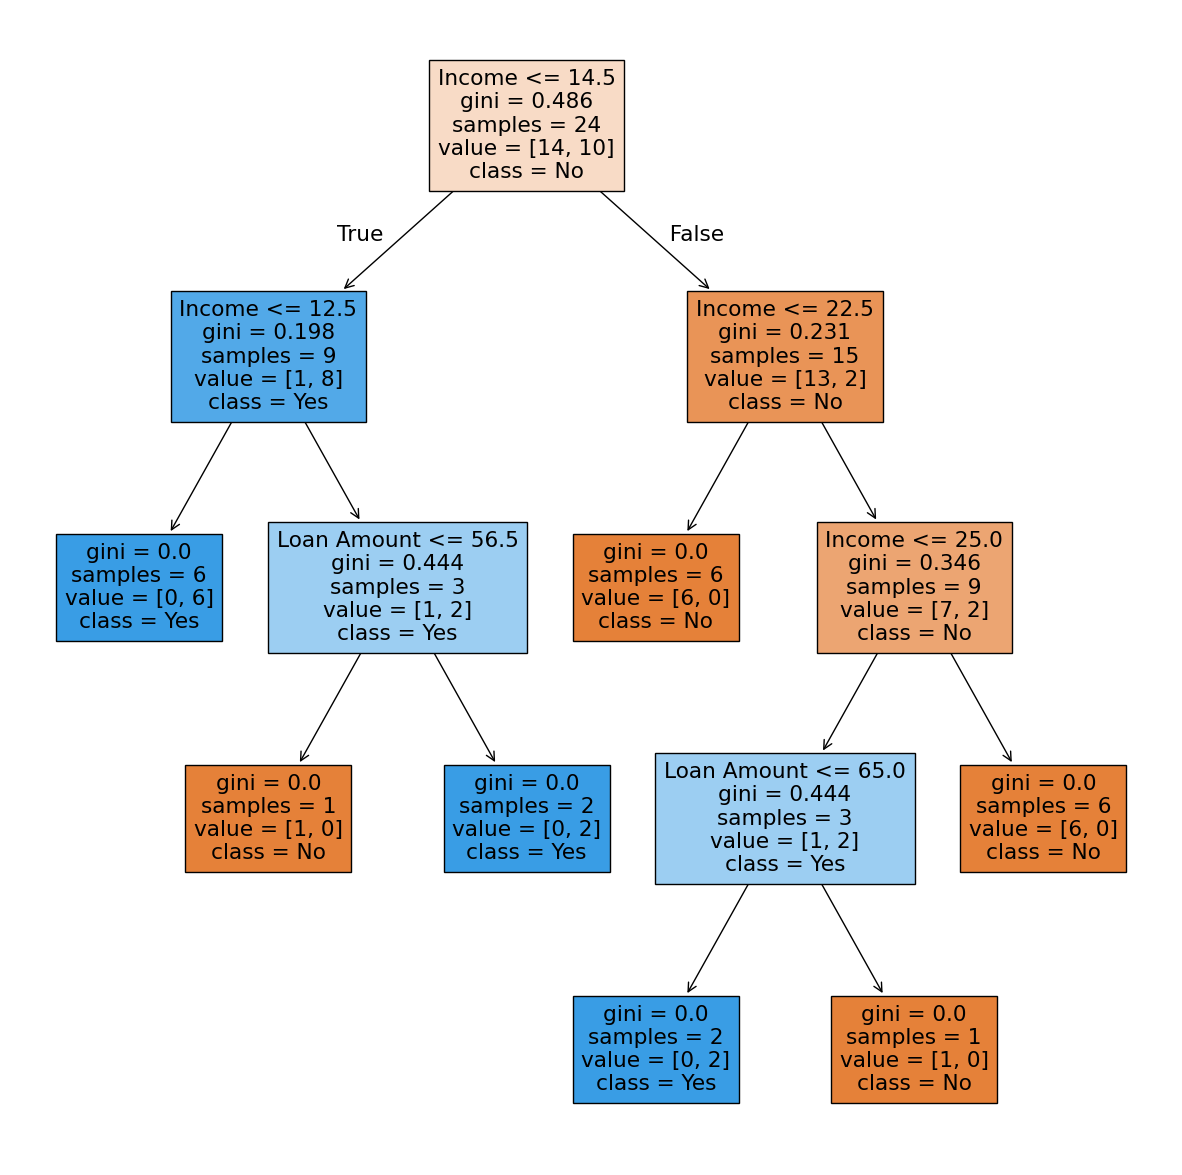

In [19]:
from sklearn import tree
plt.figure(figsize=(15,15))
tree.plot_tree(model,
               feature_names = list(x.columns),
               class_names = ['No', 'Yes'],
               filled=True)

Text(0, 0.5, 'Importance')

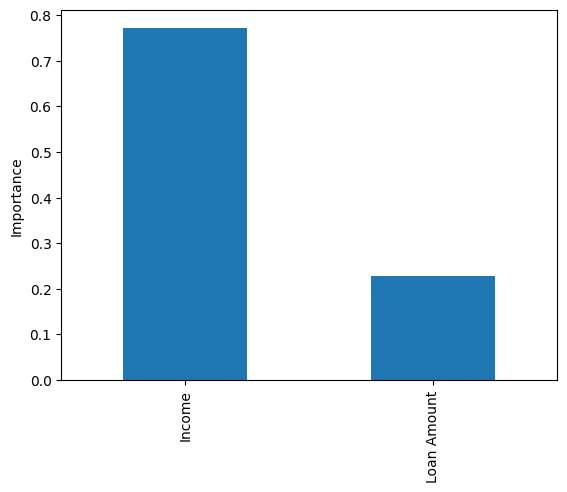

In [22]:
importance = model.feature_importances_
feature_importance = pd.Series(importance, index=x.columns)
feature_importance.plot(kind='bar')
plt.ylabel('Importance')

In [25]:
# Prune the Tree

In [27]:
model.score(x_train, y_train)

1.0

In [29]:
model.score(x_test, y_test)

0.5

In [33]:
grid = {
    'max_depth': [2,3,4,5],
    'min_samples_split': [2,3,4],
    'min_samples_leaf': [1,2,3,4,5,6]
}

In [35]:
from sklearn.model_selection import GridSearchCV
classifier = DecisionTreeClassifier(random_state=1234)
gcv = GridSearchCV(estimator=classifier, param_grid=grid)
gcv.fit(x_train, y_train)

GridSearchCV(estimator=DecisionTreeClassifier(random_state=1234),
             param_grid={'max_depth': [2, 3, 4, 5],
                         'min_samples_leaf': [1, 2, 3, 4, 5, 6],
                         'min_samples_split': [2, 3, 4]})

In [38]:
model_ = gcv.best_estimator_
model_.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=6, random_state=1234)

In [40]:
model_.score(x_train, y_train)

0.875

In [42]:
model_.score(x_test, y_test)

0.8333333333333334

[Text(0.4, 0.8333333333333334, 'Income <= 14.5\ngini = 0.486\nsamples = 24\nvalue = [14, 10]\nclass = No'),
 Text(0.2, 0.5, 'gini = 0.198\nsamples = 9\nvalue = [1, 8]\nclass = Yes'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'Loan Amount <= 51.5\ngini = 0.231\nsamples = 15\nvalue = [13, 2]\nclass = No'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.346\nsamples = 9\nvalue = [7, 2]\nclass = No'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]\nclass = No')]

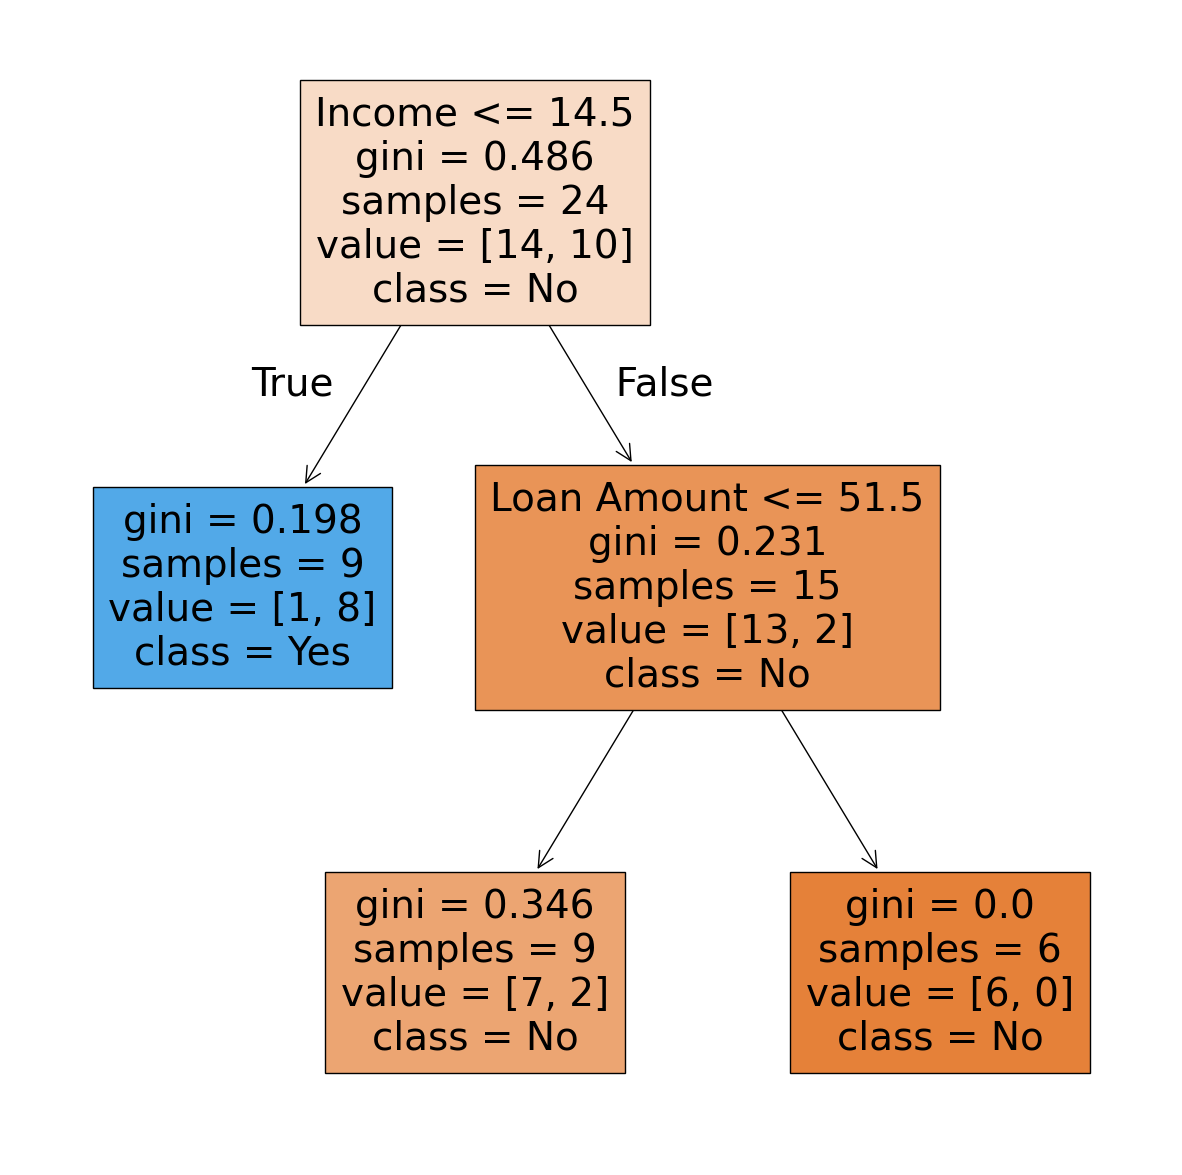

In [43]:
plt.figure(figsize=(15,15))
tree.plot_tree(model_,
               feature_names = x.columns,
               class_names = ['No', 'Yes'],
               filled=True)